# Notebook 05 — Perbandingan Antar Varian

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UBM-ML/REPLACE-WITH-YOUR-REPO/blob/main/notebooks/05_comparison.ipynb)

**Anggota yang menggabungkan:** _isi nama di sini_

---

Notebook ini **membaca file CSV history** yang sudah dihasilkan oleh keempat varian (file ada di folder `results/`), lalu menggabungkannya menjadi tabel ringkasan dan grafik komparatif.

**Prasyarat:** keempat anggota sudah commit notebook varian masing-masing dan file `results/*.csv` sudah ada di repo.

In [3]:
import os
if not os.path.exists('src'):
    # Ganti URL di bawah dengan URL repo kelompok kamu
    # URL harus menunjuk ke root repositori, bukan ke sebuah file
    REPO_URL = 'https://github.com/UBM-ML/artificial-neural-network-ml-gas'
    !git clone $REPO_URL repo
    %cd repo
print('Working dir:', os.getcwd())
print('Contents:', os.listdir('.'))

Cloning into 'repo'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 59 (delta 20), reused 1 (delta 1), pack-reused 22 (from 2)
Receiving objects: 100% (59/59), 188.90 KiB | 14.53 MiB/s, done.
Resolving deltas: 100% (22/22), done.
/content/repo
Working dir: /content/repo
Contents: ['requirements.txt', 'docs', 'Valwa Giraldy-32230178 02_mlp_sigmoid.ipynb', 'data', 'notebooks', 'scripts', 'README.md', 'src', '.git', '.gitignore', '.github', 'results', '01_single_layer.ipynb', '03_mlp_tanh.ipynb']


TensorFlow version: 2.20.0
Jumlah fitur: 4, jumlah kelas: 3
X_train: (120, 4), X_test: (30, 4)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
12/12 - 1s - 78ms/step - accuracy: 0.2188 - loss: 2.0837 - val_accuracy: 0.1667 - val_loss: 1.9985
Epoch 2/100
12/12 - 0s - 8ms/step - accuracy: 0.2188 - loss: 2.0308 - val_accuracy: 0.1667 - val_loss: 1.9549
Epoch 3/100
12/12 - 0s - 11ms/step - accuracy: 0.2188 - loss: 1.9789 - val_accuracy: 0.1667 - val_loss: 1.9119
Epoch 4/100
12/12 - 0s - 8ms/step - accuracy: 0.2188 - loss: 1.9278 - val_accuracy: 0.1250 - val_loss: 1.8695
Epoch 5/100
12/12 - 0s - 8ms/step - accuracy: 0.2188 - loss: 1.8775 - val_accuracy: 0.1250 - val_loss: 1.8277
Epoch 6/100
12/12 - 0s - 8ms/step - accuracy: 0.2292 - loss: 1.8281 - val_accuracy: 0.1250 - val_loss: 1.7866
Epoch 7/100
12/12 - 0s - 8ms/step - accuracy: 0.2396 - loss: 1.7797 - val_accuracy: 0.1250 - val_loss: 1.7462
Epoch 8/100
12/12 - 0s - 8ms/step - accuracy: 0.2604 - loss: 1.7322 - val_accuracy: 0.1250 - val_loss: 1.7066
Epoch 9/100
12/12 - 0s - 8ms/step - accuracy: 0.2604 - loss: 1.6856 - val_accuracy: 0.1250 - val_loss: 1.6677
Epoch 10

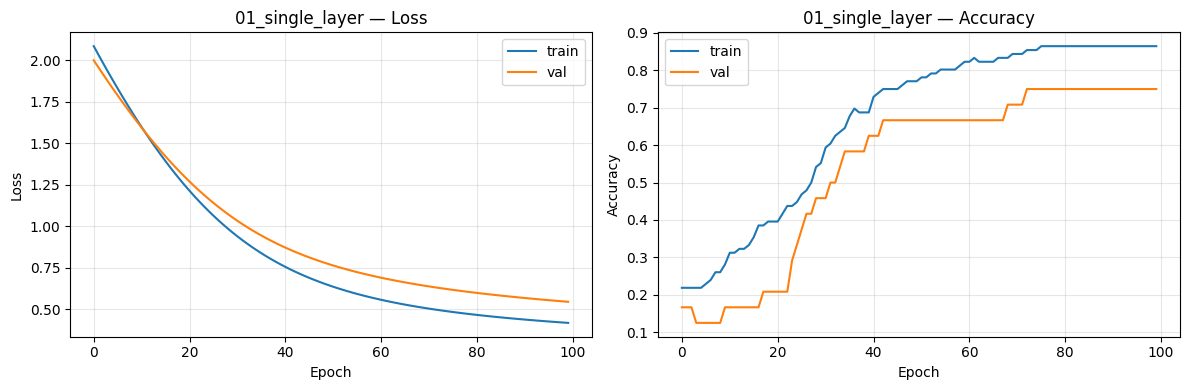


📊 01_single_layer
   Test loss:     0.5789
   Test accuracy: 0.7667
   Jumlah parameter: 15
✅ History tersimpan di: results/01_single_layer.csv


{'variant': '01_single_layer',
 'test_loss': 0.578898012638092,
 'test_accuracy': 0.7666666507720947,
 'n_params': 15}

In [4]:
#no 1
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

from src.data_loader import load_iris_data
from src.utils import set_global_seed, plot_training_curves, save_history, evaluate_and_report
from src.config import EPOCHS, BATCH_SIZE, OPTIMIZER, LOSS, METRICS, VALIDATION_SPLIT, RANDOM_SEED

set_global_seed(RANDOM_SEED)
print('TensorFlow version:', tf.__version__)

X_train, X_test, y_train, y_test, n_features, n_classes = load_iris_data()
print(f'Jumlah fitur: {n_features}, jumlah kelas: {n_classes}')
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

model = Sequential([
    Input(shape=(n_features,)),
    Dense(n_classes, activation='softmax'),  # langsung ke output
])
model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=METRICS)
model.summary()

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    verbose=2,
)

plot_training_curves(history, variant_name='01_single_layer')



summary = evaluate_and_report(model, X_test, y_test, variant_name='01_single_layer')
save_history(history, variant_name='01_single_layer')
summary


Jumlah fitur: 4, jumlah kelas: 3
X_train: (120, 4), X_test: (30, 4)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
12/12 - 1s - 85ms/step - accuracy: 0.3125 - loss: 1.3767 - val_accuracy: 0.4167 - val_loss: 1.2104
Epoch 2/100
12/12 - 0s - 8ms/step - accuracy: 0.3125 - loss: 1.3086 - val_accuracy: 0.4167 - val_loss: 1.1741
Epoch 3/100
12/12 - 0s - 8ms/step - accuracy: 0.3125 - loss: 1.2490 - val_accuracy: 0.4167 - val_loss: 1.1426
Epoch 4/100
12/12 - 0s - 8ms/step - accuracy: 0.3125 - loss: 1.1961 - val_accuracy: 0.4167 - val_loss: 1.1153
Epoch 5/100
12/12 - 0s - 12ms/step - accuracy: 0.3125 - loss: 1.1494 - val_accuracy: 0.4167 - val_loss: 1.0913
Epoch 6/100
12/12 - 0s - 8ms/step - accuracy: 0.3125 - loss: 1.1080 - val_accuracy: 0.3750 - val_loss: 1.0698
Epoch 7/100
12/12 - 0s - 8ms/step - accuracy: 0.2917 - loss: 1.0711 - val_accuracy: 0.1667 - val_loss: 1.0502
Epoch 8/100
12/12 - 0s - 8ms/step - accuracy: 0.3958 - loss: 1.0379 - val_accuracy: 0.2500 - val_loss: 1.0319
Epoch 9/100
12/12 - 0s - 8ms/step - accuracy: 0.5312 - loss: 1.0076 - val_accuracy: 0.4583 - val_loss: 1.0144
Epoch 10

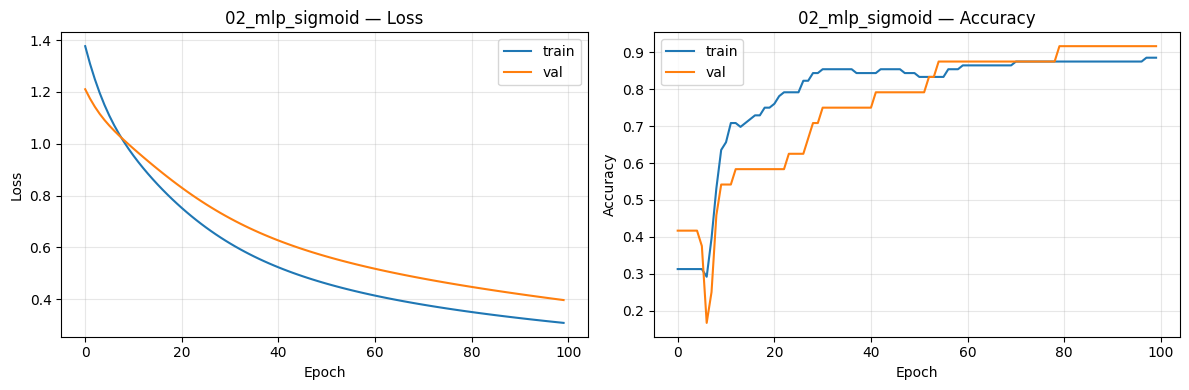


📊 02_mlp_sigmoid
   Test loss:     0.3732
   Test accuracy: 0.8333
   Jumlah parameter: 131
✅ History tersimpan di: results/02_mlp_sigmoid.csv


{'variant': '02_mlp_sigmoid',
 'test_loss': 0.37315744161605835,
 'test_accuracy': 0.8333333134651184,
 'n_params': 131}

In [5]:
#no 2

X_train, X_test, y_train, y_test, n_features, n_classes = load_iris_data()
print(f'Jumlah fitur: {n_features}, jumlah kelas: {n_classes}')
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

model = Sequential([
    Input(shape=(n_features,)),
    Dense(16, activation='sigmoid'),
    Dense(n_classes, activation='softmax'),
])
model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=METRICS)
model.summary()

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    verbose=2,
)

plot_training_curves(history, variant_name='02_mlp_sigmoid')
summary = evaluate_and_report(model, X_test, y_test, variant_name='02_mlp_sigmoid')
save_history(history, variant_name='02_mlp_sigmoid')
summary

TensorFlow version: 2.20.0
Jumlah fitur: 4, jumlah kelas: 3
X_train: (120, 4), X_test: (30, 4)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
12/12 - 1s - 86ms/step - accuracy: 0.6042 - loss: 0.9704 - val_accuracy: 0.5833 - val_loss: 0.9369
Epoch 2/100
12/12 - 0s - 8ms/step - accuracy: 0.6875 - loss: 0.8561 - val_accuracy: 0.6250 - val_loss: 0.8541
Epoch 3/100
12/12 - 0s - 15ms/step - accuracy: 0.6979 - loss: 0.7624 - val_accuracy: 0.6667 - val_loss: 0.7861
Epoch 4/100
12/12 - 0s - 32ms/step - accuracy: 0.8021 - loss: 0.6869 - val_accuracy: 0.7500 - val_loss: 0.7311
Epoch 5/100
12/12 - 0s - 33ms/step - accuracy: 0.8333 - loss: 0.6269 - val_accuracy: 0.7500 - val_loss: 0.6866
Epoch 6/100
12/12 - 0s - 12ms/step - accuracy: 0.8438 - loss: 0.5789 - val_accuracy: 0.7917 - val_loss: 0.6502
Epoch 7/100
12/12 - 1s - 51ms/step - accuracy: 0.8438 - loss: 0.5402 - val_accuracy: 0.7917 - val_loss: 0.6199
Epoch 8/100
12/12 - 0s - 13ms/step - accuracy: 0.8438 - loss: 0.5086 - val_accuracy: 0.8333 - val_loss: 0.5943
Epoch 9/100
12/12 - 0s - 26ms/step - accuracy: 0.8542 - loss: 0.4822 - val_accuracy: 0.8333 - val_loss: 0.5723
Ep

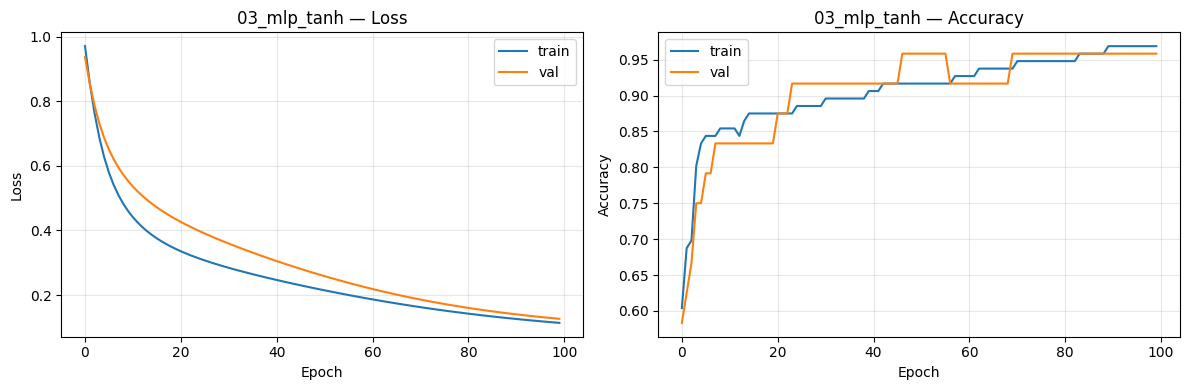


📊 03_mlp_tanh
   Test loss:     0.1463
   Test accuracy: 0.9333
   Jumlah parameter: 131
✅ History tersimpan di: results/03_mlp_tanh.csv


{'variant': '03_mlp_tanh',
 'test_loss': 0.14628788828849792,
 'test_accuracy': 0.9333333373069763,
 'n_params': 131}

In [6]:
#no 3
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

from src.data_loader import load_iris_data
from src.utils import set_global_seed, plot_training_curves, save_history, evaluate_and_report
from src.config import EPOCHS, BATCH_SIZE, OPTIMIZER, LOSS, METRICS, VALIDATION_SPLIT, RANDOM_SEED

set_global_seed(RANDOM_SEED)
print('TensorFlow version:', tf.__version__)

X_train, X_test, y_train, y_test, n_features, n_classes = load_iris_data()
print(f'Jumlah fitur: {n_features}, jumlah kelas: {n_classes}')
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

model = Sequential([
    Input(shape=(n_features,)),
    Dense(16, activation='tanh'),
    Dense(n_classes, activation='softmax'),
])
model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=METRICS)
model.summary()

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    verbose=2,
)

plot_training_curves(history, variant_name='03_mlp_tanh')
summary = evaluate_and_report(model, X_test, y_test, variant_name='03_mlp_tanh')
save_history(history, variant_name='03_mlp_tanh')
summary


TensorFlow version: 2.20.0
Jumlah fitur: 4, jumlah kelas: 3
X_train: (120, 4), X_test: (30, 4)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739 (2.89 KB)

 Trainable params: 739 (2.89 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
12/12 - 1s - 106ms/step - accuracy: 0.5417 - loss: 0.9569 - val_accuracy: 0.7083 - val_loss: 0.8753
Epoch 2/100
12/12 - 0s - 8ms/step - accuracy: 0.8229 - loss: 0.8131 - val_accuracy: 0.7083 - val_loss: 0.7809
Epoch 3/100
12/12 - 0s - 9ms/step - accuracy: 0.8542 - loss: 0.7051 - val_accuracy: 0.7500 - val_loss: 0.7057
Epoch 4/100
12/12 - 0s - 10ms/step - accuracy: 0.8333 - loss: 0.6206 - val_accuracy: 0.7083 - val_loss: 0.6427
Epoch 5/100
12/12 - 0s - 9ms/step - accuracy: 0.8438 - loss: 0.5516 - val_accuracy: 0.7083 - val_loss: 0.5892
Epoch 6/100
12/12 - 0s - 8ms/step - accuracy: 0.8542 - loss: 0.4944 - val_accuracy: 0.7917 - val_loss: 0.5450
Epoch 7/100
12/12 - 0s - 9ms/step - accuracy: 0.8542 - loss: 0.4477 - val_accuracy: 0.8333 - val_loss: 0.5080
Epoch 8/100
12/12 - 0s - 9ms/step - accuracy: 0.8542 - loss: 0.4090 - val_accuracy: 0.8750 - val_loss: 0.4751
Epoch 9/100
12/12 - 0s - 9ms/step - accuracy: 0.8542 - loss: 0.3767 - val_accuracy: 0.8750 - val_loss: 0.4458
Epoch 1

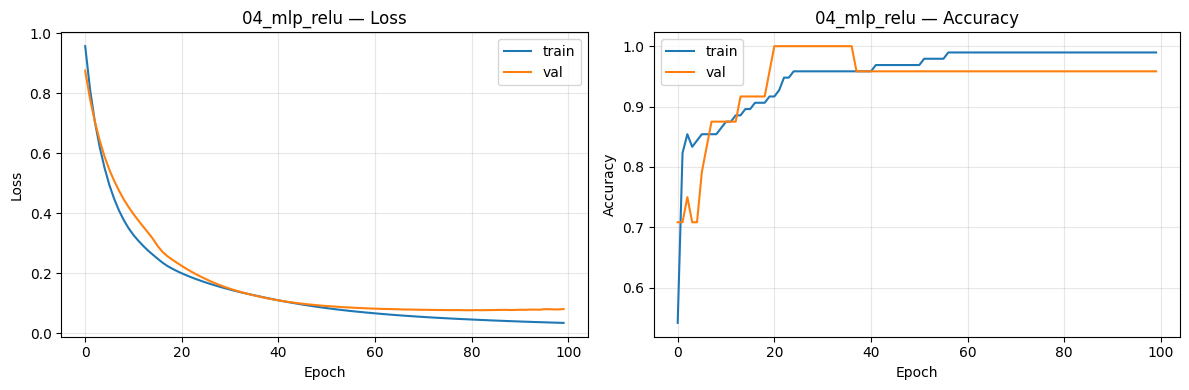


📊 04_mlp_relu
   Test loss:     0.1025
   Test accuracy: 0.9333
   Jumlah parameter: 739
✅ History tersimpan di: results/04_mlp_relu.csv


{'variant': '04_mlp_relu',
 'test_loss': 0.10249059647321701,
 'test_accuracy': 0.9333333373069763,
 'n_params': 739}

In [7]:
#no 4

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

from src.data_loader import load_iris_data
from src.utils import set_global_seed, plot_training_curves, save_history, evaluate_and_report
from src.config import EPOCHS, BATCH_SIZE, OPTIMIZER, LOSS, METRICS, VALIDATION_SPLIT, RANDOM_SEED

set_global_seed(RANDOM_SEED)
print('TensorFlow version:', tf.__version__)

X_train, X_test, y_train, y_test, n_features, n_classes = load_iris_data()
print(f'Jumlah fitur: {n_features}, jumlah kelas: {n_classes}')
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

model = Sequential([
    Input(shape=(n_features,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(n_classes, activation='softmax'),
])
model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=METRICS)
model.summary()

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    verbose=2,
)

plot_training_curves(history, variant_name='04_mlp_relu')

summary = evaluate_and_report(model, X_test, y_test, variant_name='04_mlp_relu')
save_history(history, variant_name='04_mlp_relu')
summary


## 1. Setup

In [8]:
# Jalankan cell ini HANYA jika kamu berada di Google Colab.
# Kalau kamu menjalankan di lokal/Jupyter, cukup pastikan kamu berada di root repo.

import os
if not os.path.exists('src'):
    # Ganti URL di bawah dengan URL repo kelompok kamu
    REPO_URL = 'https://github.com/REPLACE-WITH-YOUR-ORG/REPLACE-WITH-YOUR-REPO.git'
    !git clone $REPO_URL repo
    %cd repo
print('Working dir:', os.getcwd())
print('Contents:', os.listdir('.'))


Working dir: /content/repo
Contents: ['requirements.txt', 'docs', 'Valwa Giraldy-32230178 02_mlp_sigmoid.ipynb', 'data', 'notebooks', 'scripts', 'README.md', 'src', '.git', '.gitignore', '.github', 'results', '01_single_layer.ipynb', '03_mlp_tanh.ipynb']


In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = 'results'
files = sorted([f for f in os.listdir(RESULTS_DIR) if f.endswith('.csv')])
print('Ditemukan file:', files)


Ditemukan file: ['01_single_layer.csv', '02_mlp_sigmoid.csv', '03_mlp_tanh.csv', '04_mlp_relu.csv']


## 2. Gabungkan semua history

In [10]:
dfs = []
for f in files:
    df = pd.read_csv(os.path.join(RESULTS_DIR, f))
    dfs.append(df)
all_history = pd.concat(dfs, ignore_index=True)
all_history.head()


,accuracy,loss,val_accuracy,val_loss,epoch,variant
0,0.21875,2.083679,0.166667,1.998502,1,01_single_layer
1,0.21875,2.030791,0.166667,1.954946,2,01_single_layer
2,0.21875,1.978927,0.166667,1.911913,3,01_single_layer
3,0.21875,1.927821,0.125000,1.869472,4,01_single_layer
4,0.21875,1.877537,0.125000,1.827682,5,01_single_layer


## 3. Tabel akurasi akhir per varian

In [11]:
final = all_history.sort_values('epoch').groupby('variant').tail(1)
summary = final[['variant', 'loss', 'val_loss', 'accuracy', 'val_accuracy']]
summary = summary.sort_values('val_accuracy', ascending=False).reset_index(drop=True)
summary


,variant,loss,val_loss,accuracy,val_accuracy
0,03_mlp_tanh,0.113794,0.126471,0.968750,0.958333
1,04_mlp_relu,0.034608,0.080660,0.989583,0.958333
2,02_mlp_sigmoid,0.308177,0.396302,0.885417,0.916667
3,01_single_layer,0.416680,0.543707,0.864583,0.750000


## 4. Plot validation accuracy semua varian

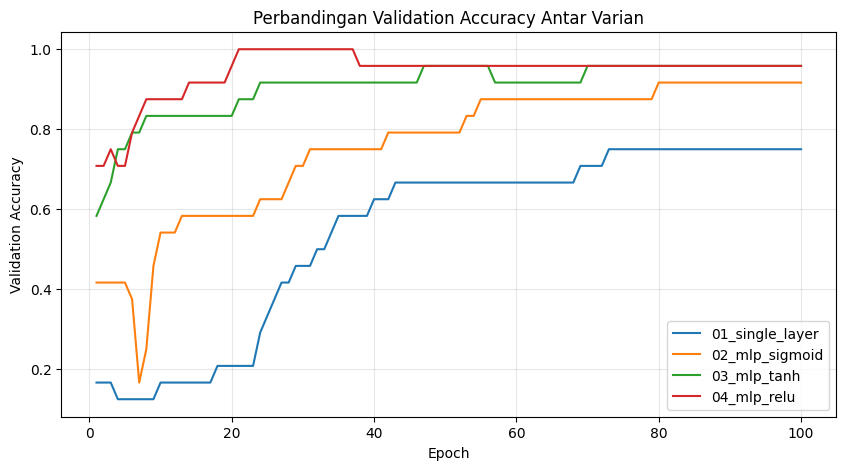

In [12]:
plt.figure(figsize=(10, 5))
for variant, df in all_history.groupby('variant'):
    plt.plot(df['epoch'], df['val_accuracy'], label=variant)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Perbandingan Validation Accuracy Antar Varian')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 5. Plot validation loss semua varian

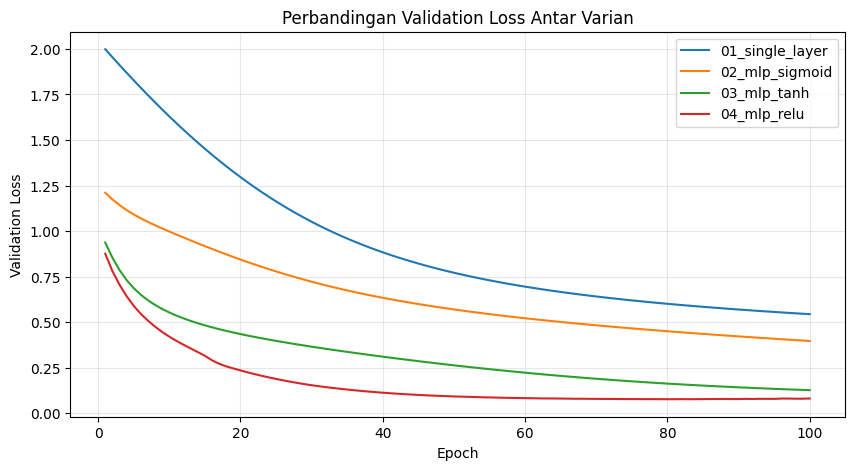

In [14]:
plt.figure(figsize=(10, 5))
for variant, df in all_history.groupby('variant'):
    plt.plot(df['epoch'], df['val_loss'], label=variant)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Perbandingan Validation Loss Antar Varian')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 6. Diskusi kelompok
Berdasarkan tabel dan grafik di atas, **isi `docs/REPORT.md`** dengan analisis kelompok. Jangan hanya mendeskripsikan grafik — kaitkan dengan teori di slide kuliah.